# Classificação de textos utilizando o Keras

Este notebook que demonstra o uso de aprendizado de máquina para a classificação de sentimentos em resenhas de filmes do IMDB. Será utilizada uma Rede Neural Artificial (RNA) recorrente com célula LSTM para resolver o problema

## Importando as bibliotecas que serão utilizadas

In [1]:
# Importando bibliotecas necessárias
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
import matplotlib.pyplot as plt

## Carregando os dados
Neste caso será utilizado um dataset presente no Keras, que é o IMDB.

O IMDb (Internet Movie Database) é a fonte mais popular para informações sobre filmes, programas de TV e celebridades. Ele fornece classificações e avaliações para os filmes e programas de TV mais recentes. Os usuários podem votar e deixar resenhas para compartilhar suas opiniões.

In [2]:
# Carregando o conjunto de dados IMDB
max_features = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Pré-processamento dos Dados

Nesta etapa serão padronizados ods tamanhos das entradas para facilitar o processamento

In [5]:
# Pré-processamento dos dados
maxlen = 200
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

In [14]:
y_train[9]

0

In [10]:
text, arr = get_plain_text(0)
print(text)
print(arr)

[START] please give this one a miss br br kristy swanson and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite lacklustre so all you madison fans give this a miss
[1, 591, 202, 14, 31, 6, 717, 10, 10, 18142, 10698, 5, 4, 360, 7, 4, 177, 5760, 394, 354, 4, 123, 9, 1035, 1035, 1035, 10, 10, 13, 92, 124, 89, 488, 7944, 100, 28, 1668, 14, 31, 23, 27, 7479, 29, 220, 468, 8, 124, 14, 286, 170, 8, 157, 46, 5, 27, 239, 16, 179, 15387, 38, 32, 25, 7944, 451, 202, 14, 6, 717]


o código a seguir recebe uma amostra do dataset, que está representada por indices das palavras de um dicionário e converte para o formato textual.

In [8]:
# código adaptado de https://keras.io/api/datasets/imdb/

def get_plain_text(index):
  # Use the default parameters to keras.datasets.imdb.load_data
  start_char = 1
  oov_char = 2
  index_from = 3
  # Retrieve the training sequences.
  _, (x_test, _) = imdb.load_data(
      start_char=start_char, oov_char=oov_char, index_from=index_from
  )
  # Retrieve the word index file mapping words to indices
  word_index = imdb.get_word_index()
  # Reverse the word index to obtain a dict mapping indices to words
  # And add `index_from` to indices to sync with `x_train`
  inverted_word_index = dict(
      (i + index_from, word) for (word, i) in word_index.items()
  )
  # Update `inverted_word_index` to include `start_char` and `oov_char`
  inverted_word_index[start_char] = "[START]"
  inverted_word_index[oov_char] = "[OOV]"
  # Decode the first sequence in the dataset
  decoded_sequence = " ".join(inverted_word_index[i] for i in x_test[index])

  return decoded_sequence, x_test[index]

#Construindo o Modelo
Será criada uma RNA para classificar as avaliações como positivas ou negativas.

Usaremos as seguintes camadas na nossa RNA:
* **Embedding**: pré-processamento
* **LSTM**: extração de características
* **Dense**: para classificação
* **Função de ativação**: Sigmoide

In [15]:
model = Sequential()
model.add(Embedding(max_features, 128))
model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

## Treinamento e Avaliação

Treinaremos o modelo com os dados de treinamento e avaliaremos sua precisão com os dados de teste.

In [16]:
# Treinando o modelo
history = model.fit(x_train, y_train, epochs=3, batch_size=256, validation_split=0.2)

Epoch 1/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 36s 359ms/step - accuracy: 0.6374 - loss: 0.6229 - val_accuracy: 0.8258 - val_loss: 0.3943
Epoch 2/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 37s 365ms/step - accuracy: 0.8573 - loss: 0.3475 - val_accuracy: 0.8540 - val_loss: 0.3560
Epoch 3/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 358ms/step - accuracy: 0.8873 - loss: 0.2905 - val_accuracy: 0.8332 - val_loss: 0.4057


## Visualização dos Resultados

Apresentaremos visualmente as métricas de desempenho, como matriz de confusão e curva ROC.

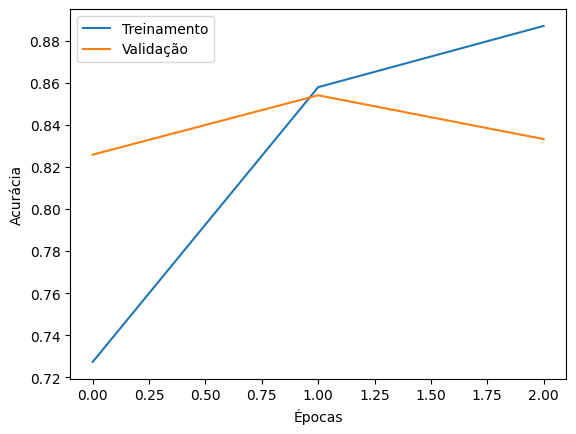

In [17]:
# Visualizando a acurácia durante o treinamento
plt.plot(history.history['accuracy'], label='Treinamento')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

In [18]:
# Fazendo previsões nas avaliações de teste
predictions = model.predict(x_test)

# Convertendo as previsões para classes (positivo ou negativo)
predicted_classes = (predictions > 0.5).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 84ms/step


In [21]:
acertos = 0
erros = 0
for i in range(len(predicted_classes)):
  if predicted_classes[i] == y_test[i]:
    acertos += 1
  else:
    erros += 1

In [22]:
print(f"Acurácia: {acertos/len(y_test)}")

Acurácia: 0.82672


In [23]:
# Exibindo algumas previsões
for i in range(5):
    print(f"Avaliação {i + 1}:")
    print(f"Texto: {get_plain_text(i)}")
    print(f"Previsão: {'Positivo' if predicted_classes[i] == 1 else 'Negativo'}")
    print(f"Real: {'Positivo' if y_test[i] == 1 else 'Negativo'}")
    print("-" * 30)

# Avaliando o modelo
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Acurácia no conjunto de teste: {test_acc:.4f}")

Avaliação 1:
Texto: ("[START] please give this one a miss br br kristy swanson and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite lacklustre so all you madison fans give this a miss", [1, 591, 202, 14, 31, 6, 717, 10, 10, 18142, 10698, 5, 4, 360, 7, 4, 177, 5760, 394, 354, 4, 123, 9, 1035, 1035, 1035, 10, 10, 13, 92, 124, 89, 488, 7944, 100, 28, 1668, 14, 31, 23, 27, 7479, 29, 220, 468, 8, 124, 14, 286, 170, 8, 157, 46, 5, 27, 239, 16, 179, 15387, 38, 32, 25, 7944, 451, 202, 14, 6, 717])
Previsão: Negativo
Real: Negativo
------------------------------
Avaliação 2:
Texto: ("[START] this film requires a lot of patience because it focuses on mood and character development the plot is very simple and many of the scenes take place on the same set in frances austen's the sandy dennis character apar